# Lung Cancar Prediction: Basic Exploratory Data Analysis

### **Dataset Overview**

This project utilizes the **Lung Cancer Prediction Dataset**, which contains patient-level information intended for analyzing and predicting lung cancer risk. The dataset integrates a broad range of **demographic**, **lifestyle**, **environmental**, and **clinical** variables to model how multiple risk dimensions interact.

The primary objective is to predict the target variable `lung_cancer_risk`, which indicates whether an individual is classified as being at elevated risk based on combined factors.

* **Source:** [Kaggle - Lung Cancer Prediction Dataset](https://www.kaggle.com/datasets/dhrubangtalukdar/lung-cancer-prediction-dataset/data)
* **Target Variable:** `lung_cancer_risk` (Binary Classification)

### **Key Characteristics**

* **Multi-dimensional:** Incorporates clinical measurements (e.g., Oxygen Saturation), behavioral habits (e.g., Smoking), and environmental factors (e.g., Air Pollution).
* **Focus Areas:** Emphasizes cumulative smoking exposure (`pack_years`) and respiratory health history (`copd`, `asthma`).
* **Application:** Suitable for risk stratification, feature importance analysis, and healthcare decision-support prototyping.

### **Variable Descriptions**

| Variable Name | Description |
| --- | --- |
| **age** | Age of the individual in years |
| **gender** | Biological sex (0 = Female, 1 = Male) |
| **education_years** | Total years of formal education completed |
| **income_level** | Socioeconomic status on an ordinal scale (1 = lowest, 5 = highest) |
| **smoker** | Indicates whether the individual has a history of smoking (0 = No, 1 = Yes) |
| **smoking_years** | Total number of years the individual has smoked |
| **cigarettes_per_day** | Average number of cigarettes smoked per day |
| **pack_years** | Cumulative smoking exposure combining duration and intensity |
| **passive_smoking** | Exposure to secondhand smoke (0 = No, 1 = Yes) |
| **air_pollution_index** | Air quality index representing long-term pollution exposure |
| **occupational_exposure** | Exposure to hazardous substances at work (0 = No, 1 = Yes) |
| **radon_exposure** | History of radon exposure (0 = No, 1 = Yes) |
| **family_history_cancer** | Family history of cancer (0 = No, 1 = Yes) |
| **copd** | Diagnosis of chronic obstructive pulmonary disease (0 = No, 1 = Yes) |
| **asthma** | History of asthma (0 = No, 1 = Yes) |
| **previous_tb** | History of tuberculosis infection (0 = No, 1 = Yes) |
| **chronic_cough** | Presence of long-term cough symptoms (0 = No, 1 = Yes) |
| **chest_pain** | Reports of chest pain (0 = No, 1 = Yes) |
| **shortness_of_breath** | Presence of breathing difficulty (0 = No, 1 = Yes) |
| **fatigue** | Persistent fatigue symptoms (0 = No, 1 = Yes) |
| **bmi** | Body mass index category value |
| **oxygen_saturation** | Blood oxygen saturation level (%) |
| **fev1_x10** | Lung function measure derived from forced expiratory volume |
| **crp_level** | C-reactive protein level indicating inflammation |
| **xray_abnormal** | Abnormal findings in chest imaging (0 = No, 1 = Yes) |
| **exercise_hours_per_week** | Average weekly physical activity duration |
| **diet_quality** | Overall dietary quality score (1 = poor, 5 = excellent) |
| **alcohol_units_per_week** | Average alcohol consumption per week |
| **healthcare_access** | Access to healthcare services (1 = poor, 5 = excellent) |
| **lung_cancer_risk** | **(Target)** Indicator of elevated lung cancer risk (0 = No, 1 = Yes) |

---


### 1. Setup and Initialization

In [1]:
# import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set visual style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load data
df = pd.read_csv("data/lung_cancer.csv")
df.head()

,age,gender,education_years,income_level,smoker,smoking_years,cigarettes_per_day,pack_years,passive_smoking,air_pollution_index,...,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
0,60,1,20,2,1,16,15,12,0,71,...,20,94,29,6,1,5,4,13,3,1
1,53,0,12,4,0,0,0,0,1,66,...,25,96,35,4,0,5,2,0,3,0
2,62,1,15,3,1,9,29,13,1,69,...,23,95,29,9,1,1,4,2,1,1
3,73,1,12,3,0,0,0,0,0,47,...,18,96,32,0,0,0,3,10,4,0
4,52,1,13,1,0,0,0,0,0,94,...,16,97,36,8,0,6,2,9,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   age                      5000 non-null   int64
 1   gender                   5000 non-null   int64
 2   education_years          5000 non-null   int64
 3   income_level             5000 non-null   int64
 4   smoker                   5000 non-null   int64
 5   smoking_years            5000 non-null   int64
 6   cigarettes_per_day       5000 non-null   int64
 7   pack_years               5000 non-null   int64
 8   passive_smoking          5000 non-null   int64
 9   air_pollution_index      5000 non-null   int64
 10  occupational_exposure    5000 non-null   int64
 11  radon_exposure           5000 non-null   int64
 12  family_history_cancer    5000 non-null   int64
 13  copd                     5000 non-null   int64
 14  asthma                   5000 non-null   int64
 15  prev

In [4]:
df.describe()

,age,gender,education_years,income_level,smoker,smoking_years,cigarettes_per_day,pack_years,passive_smoking,air_pollution_index,...,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000
mean,54.566400,0.488200,11.510400,2.554400,0.454800,8.822200,6.685600,6.249000,0.347600,64.278800,...,23.604800,96.089200,31.475800,4.593600,0.201400,2.580400,2.534800,5.8850,2.536800,0.248800
std,11.932731,0.499911,2.953987,0.982667,0.498003,11.651598,9.032888,9.964901,0.476256,19.479809,...,3.937222,3.412385,5.213679,5.333566,0.401086,1.834178,0.985385,4.4239,0.984093,0.432361
min,18.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,...,16.000000,85.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.0000,1.000000,0.000000
25%,47.000000,0.000000,10.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,51.000000,...,21.000000,95.000000,30.000000,1.000000,0.000000,1.000000,2.000000,2.0000,2.000000,0.000000
50%,55.000000,0.000000,11.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,64.000000,...,24.000000,97.000000,33.000000,3.000000,0.000000,2.000000,3.000000,6.0000,3.000000,0.000000
75%,62.000000,1.000000,13.250000,3.000000,1.000000,18.000000,14.000000,10.000000,1.000000,78.000000,...,26.000000,99.000000,35.000000,7.000000,0.000000,4.000000,3.000000,9.0000,3.000000,0.000000
max,90.000000,1.000000,20.000000,5.000000,1.000000,52.000000,44.000000,60.000000,1.000000,130.000000,...,37.000000,100.000000,37.000000,33.000000,1.000000,10.000000,5.000000,23.0000,5.000000,1.000000


---

### 2. Target Variable analysis

checking if the dataset is balanced or not

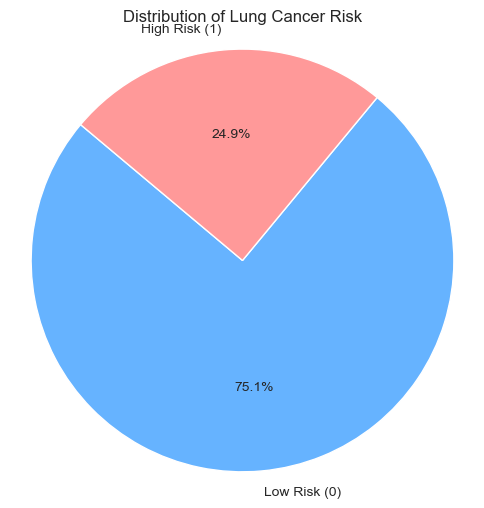

Baseline Accuracy (if we predict majority class): 75.12%


In [5]:
# Calculate the percentage of risk classes
risk_counts = df['lung_cancer_risk'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 6))
plt.pie(risk_counts, labels=['Low Risk (0)', 'High Risk (1)'], 
        autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.title('Distribution of Lung Cancer Risk')
plt.axis('equal') 
plt.show()

print(f"Baseline Accuracy (if we predict majority class): {risk_counts.max():.2f}%")

- The dataset is imbalanced, with the majority of cases (75.1%) classified as low risk.

- High-risk cases constitute the remaining 24.9% of the dataset.

---

### 3. Overview of Correlations
Now, let's look at the "Big Picture." Which features have the strongest mathematical relationship with Lung Cancer Risk? We will use a Heatmap for this.

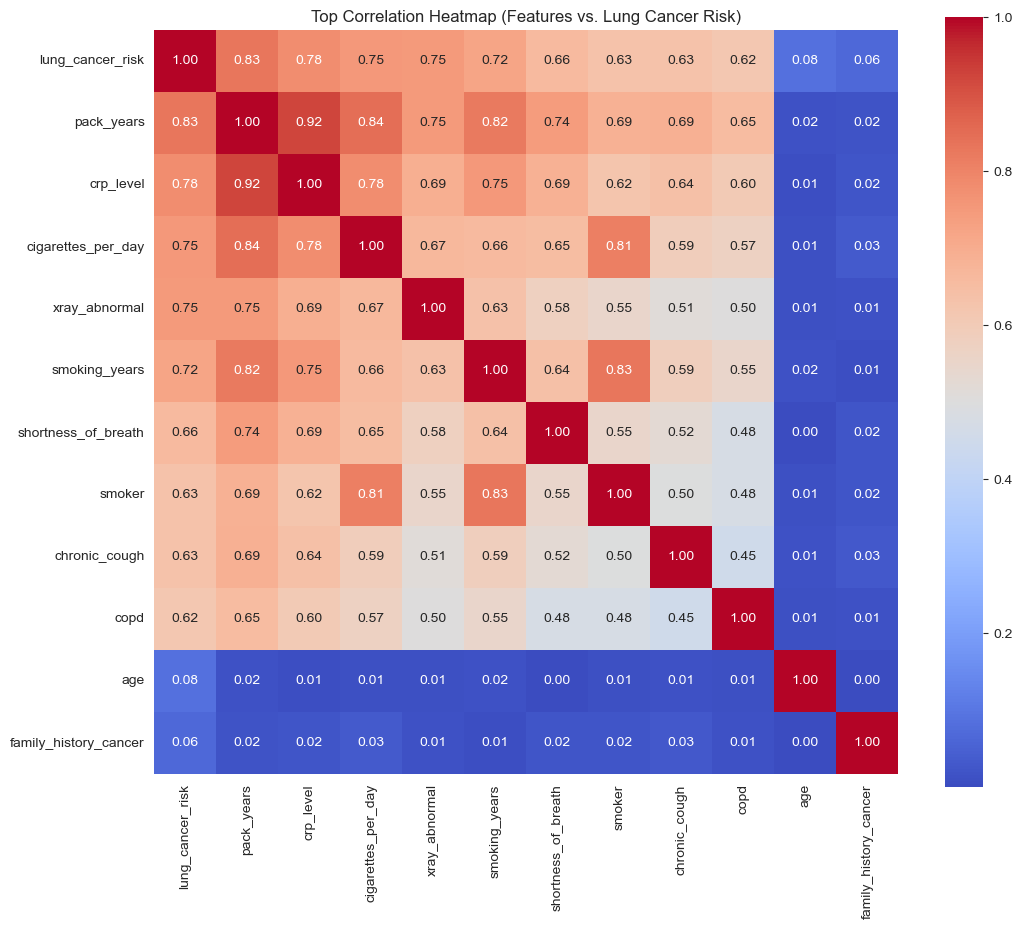

In [6]:
# Calculate correlation matrix
corr_matrix = df.corr()


k = 12 # number of variables for heatmap
cols = corr_matrix.nlargest(k, 'lung_cancer_risk')['lung_cancer_risk'].index
cm = np.corrcoef(df[cols].values.T)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', 
            annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values, cmap='coolwarm')
plt.title('Top Correlation Heatmap (Features vs. Lung Cancer Risk)')
plt.show()

- pack_years (0.83), crp_level (0.78), and cigarettes_per_day (0.75) have the strongest positive correlation with lung_cancer_risk.

- Other notable positively correlated features include smoking_years, shortness_of_breath, smoker, and xray_abnormal.

- Physiological measurements like fev1_x10 (not explicitly shown but inferred from other charts) and oxygen_saturation (not explicitly shown but inferred) likely have negative correlations.

**correlation with Target (Ranked)**


Finally, let's create a clear ranking of which features are most important. This is a great transition into the Feature Selection phase of machine learning.

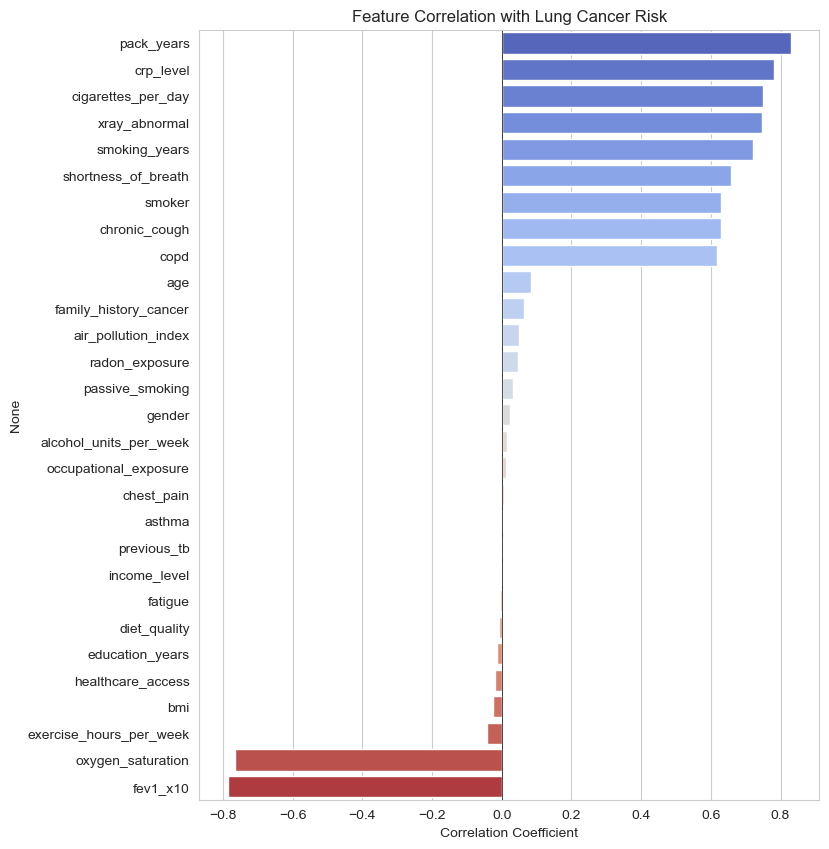

In [7]:
# Get correlation with the target variable
target_corr = df.corr()['lung_cancer_risk'].drop('lung_cancer_risk').sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')
plt.title('Feature Correlation with Lung Cancer Risk')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.show()

- The features with the strongest positive correlation to lung cancer risk are pack_years, crp_level, cigarettes_per_day, and xray_abnormal.

- The features with the strongest negative correlation are fev1_x10 and oxygen_saturation, indicating that higher values in these measurements are associated with lower risk.

---

### 4. Deep Dive: Impact of Smoking
Smoking is clinically the significant risk factor for lung cancer. Let's validate this in the data by exploring smoker, cigarettes_per_day, and pack_years.

#### A. Smoker Status vs. Risk

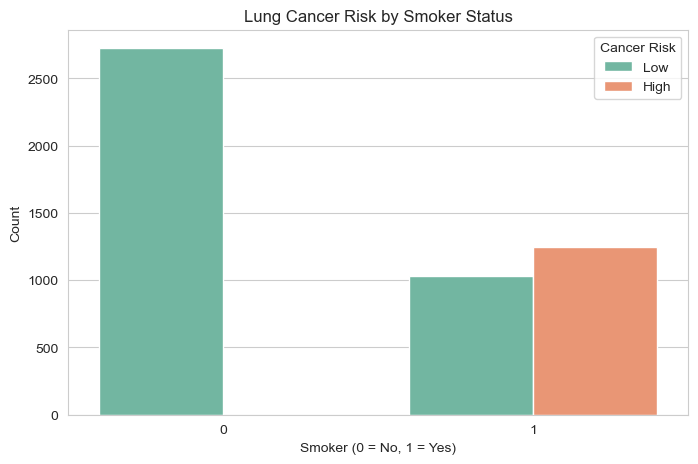

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='smoker', hue='lung_cancer_risk', palette='Set2')
plt.title('Lung Cancer Risk by Smoker Status')
plt.xlabel('Smoker (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Cancer Risk', labels=['Low', 'High'])
plt.show()

- Non-smokers are predominantly classified into the low-risk category.

- A significant portion of smokers falls into the high-risk category, indicating a clear association between smoking and elevated lung cancer risk.

#### B. Intensity of Smoking (Pack Years) 
pack_years is a calculated metric (packs per day × years smoking). It is usually a better predictor than just "years smoking."

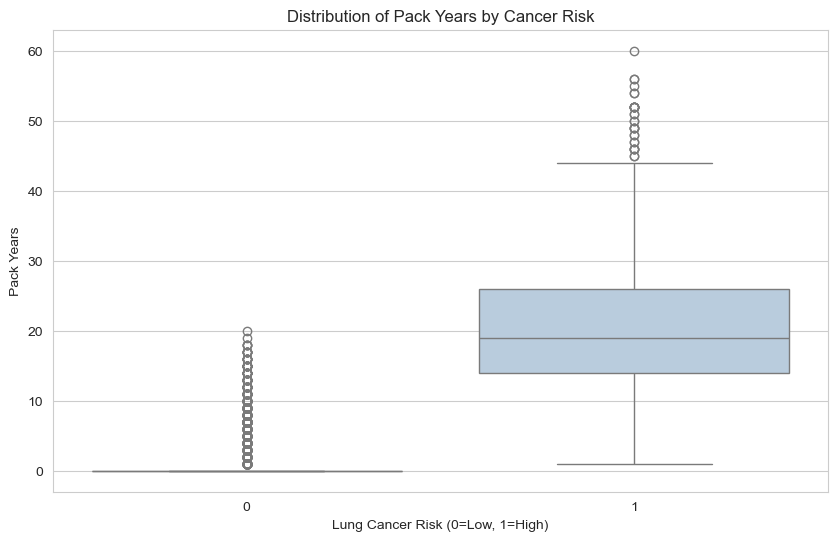

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='lung_cancer_risk', y='pack_years', palette='Pastel1')
plt.title('Distribution of Pack Years by Cancer Risk')
plt.xlabel('Lung Cancer Risk (0=Low, 1=High)')
plt.ylabel('Pack Years')
plt.show()

- Individuals in the high-risk group generally have a higher median and a wider range of 'pack years' compared to those in the low-risk group.

- There are several outliers in the low-risk group with a high number of pack years, but the overall trend shows a strong correlation between cumulative smoking exposure and high risk.

---

### 5. Physiological Indicators
Let's analyze the medical measurements: oxygen_saturation and fev1_x10 (Forced Expiratory Volume). Lower lung function often correlates with higher risk.

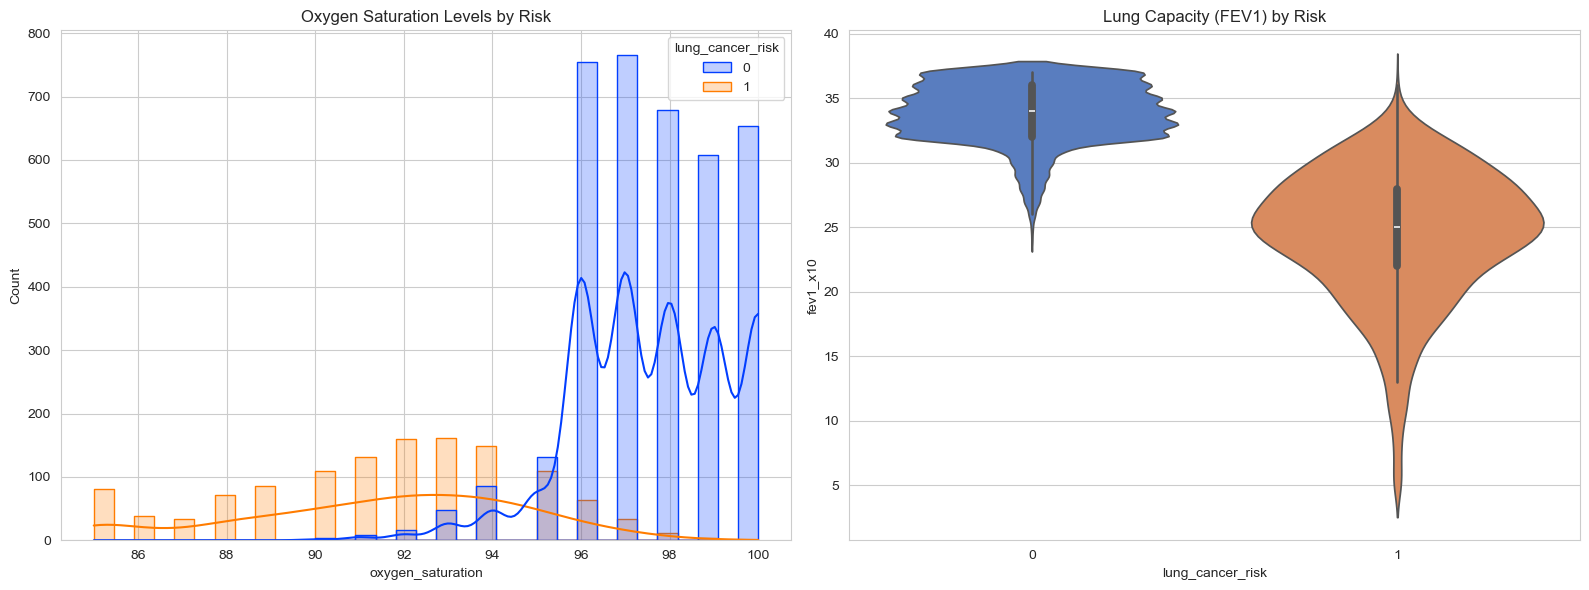

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Oxygen Saturation Distribution
sns.histplot(data=df, x='oxygen_saturation', hue='lung_cancer_risk', kde=True, element="step", ax=axes[0], palette='bright')
axes[0].set_title('Oxygen Saturation Levels by Risk')

# FEV1 Distribution (Lung Capacity)
# Note: fev1_x10 likely means the value is multiplied by 10. 
sns.violinplot(data=df, x='lung_cancer_risk', y='fev1_x10', ax=axes[1], palette='muted')
axes[1].set_title('Lung Capacity (FEV1) by Risk')

plt.tight_layout()
plt.show()

- Oxygen Saturation: High-risk individuals tend to have lower oxygen saturation levels, with a distribution shifted towards values below 96%, whereas low-risk individuals are clustered at higher saturation levels.

- Lung Capacity (FEV1): The high-risk group has a lower median lung capacity and a wider distribution compared to the low-risk group, indicating poorer lung function.

---
### 6. Symptoms Analysis
Do patients with high risk exhibit specific symptoms like chronic_cough, chest_pain, or shortness_of_breath? We can aggregate these binary columns to see the prevalence.

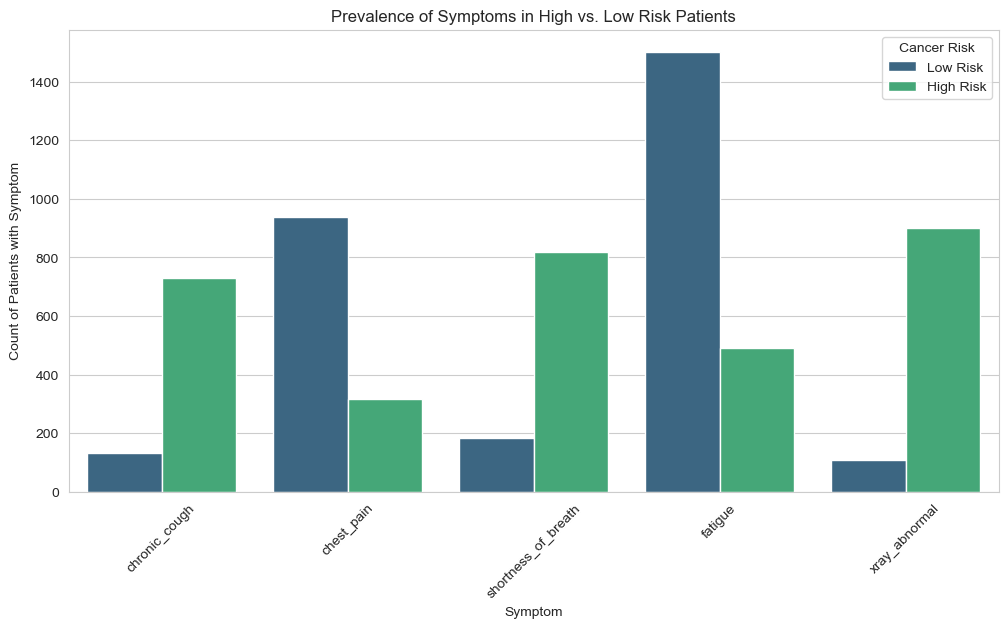

In [11]:
symptoms = ['chronic_cough', 'chest_pain', 'shortness_of_breath', 'fatigue', 'xray_abnormal']

# Melt the dataframe to make it suitable for a grouped plot
df_melted = df.melt(id_vars=['lung_cancer_risk'], value_vars=symptoms, 
                    var_name='Symptom', value_name='Presence')

# Filter only for cases where the symptom is Present (1)
df_symptoms_only = df_melted[df_melted['Presence'] == 1]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_symptoms_only, x='Symptom', hue='lung_cancer_risk', palette='viridis')
plt.title('Prevalence of Symptoms in High vs. Low Risk Patients')
plt.ylabel('Count of Patients with Symptom')
plt.xticks(rotation=45)
plt.legend(title='Cancer Risk', labels=['Low Risk', 'High Risk'])
plt.show()

- Symptoms like chronic_cough, shortness_of_breath, and xray_abnormal are much more prevalent in high-risk patients compared to low-risk patients.

- Interestingly, chest_pain and fatigue appear to be more common in the low-risk group in this dataset.

---

### 7. Environmental & Demographic Factors
Finally, let's look at age and air_pollution_index. Does exposure to high pollution correlate with the risk classes?

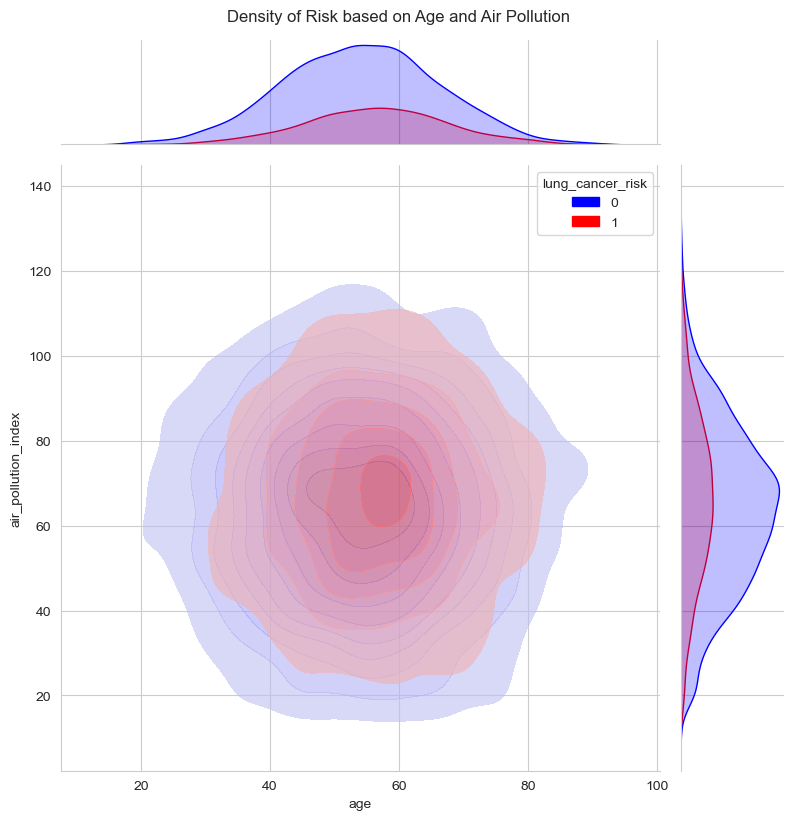

In [12]:
# Create a joint plot to see the relationship between Age, Air Pollution, and Risk
g = sns.jointplot(data=df, x='age', y='air_pollution_index', hue='lung_cancer_risk', 
                  kind='kde', fill=True, palette=['blue', 'red'], alpha=0.6, height=8)

g.fig.suptitle('Density of Risk based on Age and Air Pollution', y=1.02)
plt.show()

- High-risk cases (red) appear to be concentrated in a slightly older demographic and across a broad range of air pollution index values, with a density peak around age 55-65 and pollution index 60-80.

- Low-risk cases (blue) are also spread across similar age and pollution ranges but have a more dispersed distribution with a similar central density.

---
### 8. Data Integrity & Logical Consistency Checks
Before training a model, we must ensure the data makes sense logically. For example, a non-smoker should have 0 cigarettes_per_day. If they don't, our model might get confused.

Number of non-smokers with >0 cigarettes/day: 0
Number of smokers with 0 smoking years: 58


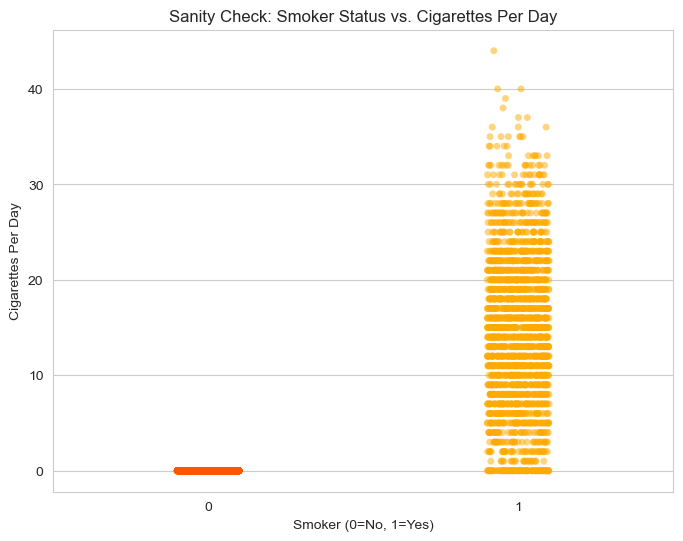

In [13]:
# Check for logical inconsistencies
# 1. Non-smokers who supposedly smoke cigarettes
inconsistent_smokers = df[(df['smoker'] == 0) & (df['cigarettes_per_day'] > 0)]
print(f"Number of non-smokers with >0 cigarettes/day: {len(inconsistent_smokers)}")

# 2. Smokers with 0 smoking years (might be new smokers, but worth checking)
new_smokers = df[(df['smoker'] == 1) & (df['smoking_years'] == 0)]
print(f"Number of smokers with 0 smoking years: {len(new_smokers)}")

# Visualizing the relationship between Smoker status and Cigarettes per day
plt.figure(figsize=(8, 6))
sns.stripplot(data=df, x='smoker', y='cigarettes_per_day', jitter=True, alpha=0.5, palette='autumn')
plt.title('Sanity Check: Smoker Status vs. Cigarettes Per Day')
plt.xlabel('Smoker (0=No, 1=Yes)')
plt.ylabel('Cigarettes Per Day')
plt.show()

- The data is logically consistent, as all non-smokers have a cigarettes_per_day value of 0.

- All individuals identified as smokers have a cigarettes_per_day value greater than 0, confirming the integrity of the smoking-related variables.

---
### 9. Genetic and Occupational Risk Factors
Lung cancer isn't just about smoking; genetics and work environment play a huge role. Let's analyze family_history_cancer and occupational_exposure.

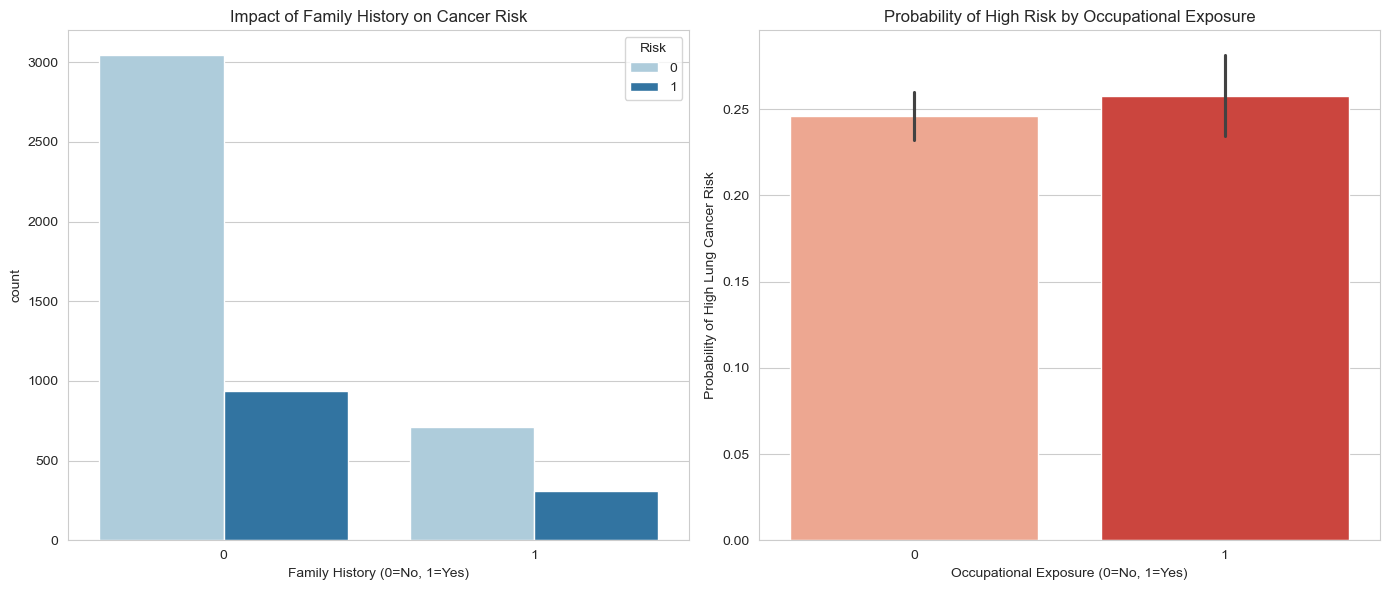

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Family History Analysis
sns.countplot(data=df, x='family_history_cancer', hue='lung_cancer_risk', ax=axes[0], palette='Paired')
axes[0].set_title('Impact of Family History on Cancer Risk')
axes[0].set_xlabel('Family History (0=No, 1=Yes)')
axes[0].legend(title='Risk', loc='upper right')

# Occupational Exposure Analysis
sns.barplot(data=df, x='occupational_exposure', y='lung_cancer_risk', ax=axes[1], palette='Reds')
axes[1].set_title('Probability of High Risk by Occupational Exposure')
axes[1].set_ylabel('Probability of High Lung Cancer Risk')
axes[1].set_xlabel('Occupational Exposure (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

- Family History: While fewer individuals have a family history of cancer, the proportion of high-risk cases within this group is notable.

- Occupational Exposure: There is a slightly higher probability of being in the high-risk category for individuals with occupational exposure compared to those without.

---
### 10. Outlier Detection

Machine learning models (especially Logistic Regression or SVMs) are sensitive to outliers. Let's look at continuous variables like bmi, air_pollution_index, and alcohol_units_per_week to see if there are extreme values.

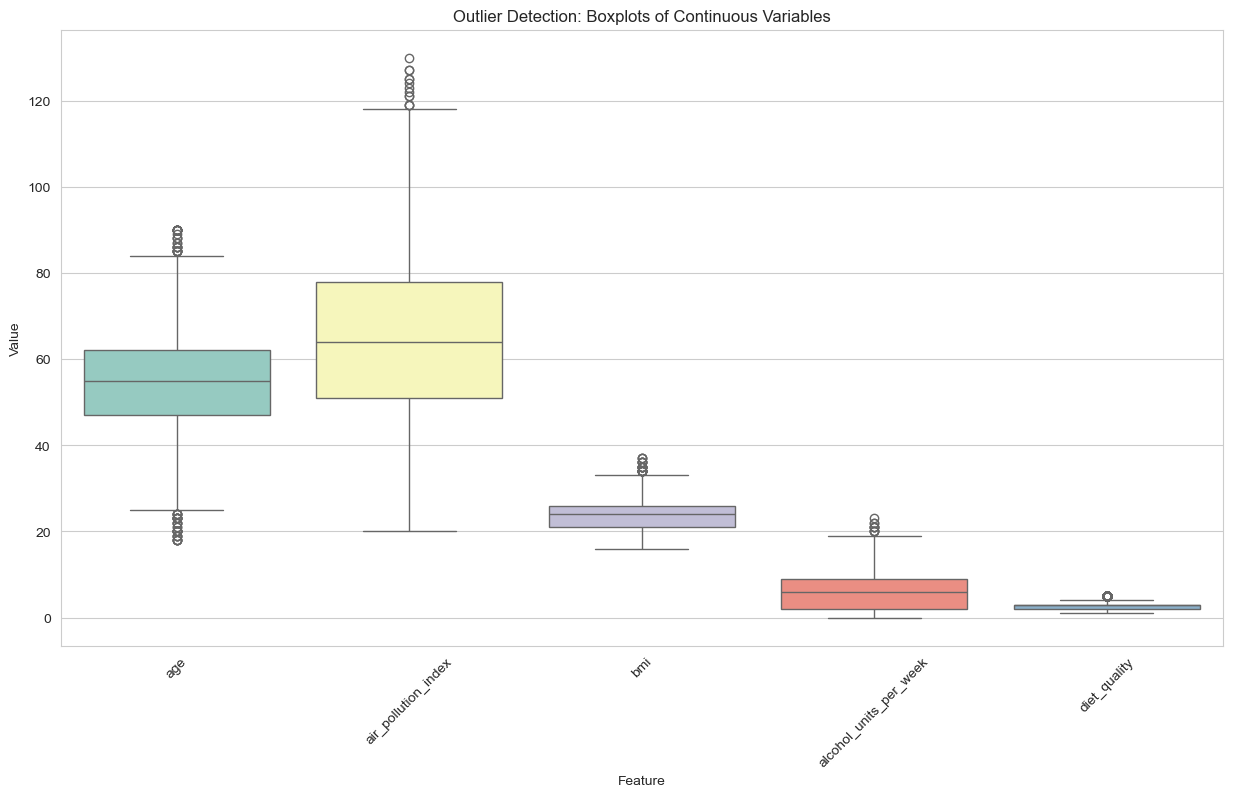

In [15]:
# Select continuous columns
continuous_cols = ['age', 'air_pollution_index', 'bmi', 'alcohol_units_per_week', 'diet_quality']

plt.figure(figsize=(15, 8))
# Create boxplots for multiple columns
df_melted_cont = df.melt(value_vars=continuous_cols, var_name='Feature', value_name='Value')

sns.boxplot(data=df_melted_cont, x='Feature', y='Value', palette='Set3')
plt.title('Outlier Detection: Boxplots of Continuous Variables')
plt.xticks(rotation=45)
plt.show()

- Varied Distributions: age and air_pollution_index have relatively symmetrical boxplots with few outliers.

- Skewed Data: alcohol_units_per_week is highly skewed towards zero (most people drink little), with several outliers on the high end. diet_quality also shows a tight distribution with some lower-end outliers.

---

### 11. Feature Engineering: Grouping Age
Age is often better analyzed in groups (bins) because the risk profile of a 20-year-old is vastly different from a 60-year-old. We will create a new feature called Age_Group and visualize it.

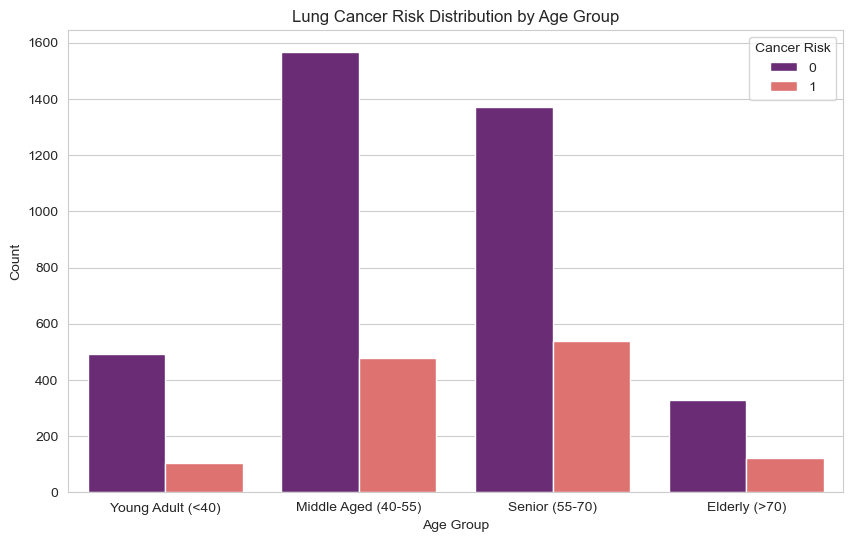

In [16]:
# Create Age Bins
bins = [0, 40, 55, 70, 100]
labels = ['Young Adult (<40)', 'Middle Aged (40-55)', 'Senior (55-70)', 'Elderly (>70)']
df['Age_Group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Visualize Risk by Age Group
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Age_Group', hue='lung_cancer_risk', palette='magma')
plt.title('Lung Cancer Risk Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Cancer Risk')
plt.show()

- Age Progression: The absolute count of high-risk cases (red bars) increases from "Young Adult" to "Middle Aged" and "Senior," before dropping in the "Elderly" group (likely due to fewer total people in that age bracket).

- Consistent Ratio: While the counts change, the ratio of high-risk to low-risk seems relatively stable across the older age groups, reinforcing the correlation heatmap finding that age itself is not the strongest linear predictor compared to lifestyle choices.

---

### 12. Multivariate Interaction: Pollution + Smoking
Does the combination of high pollution AND smoking drastically increase risk? This is an interaction effect.

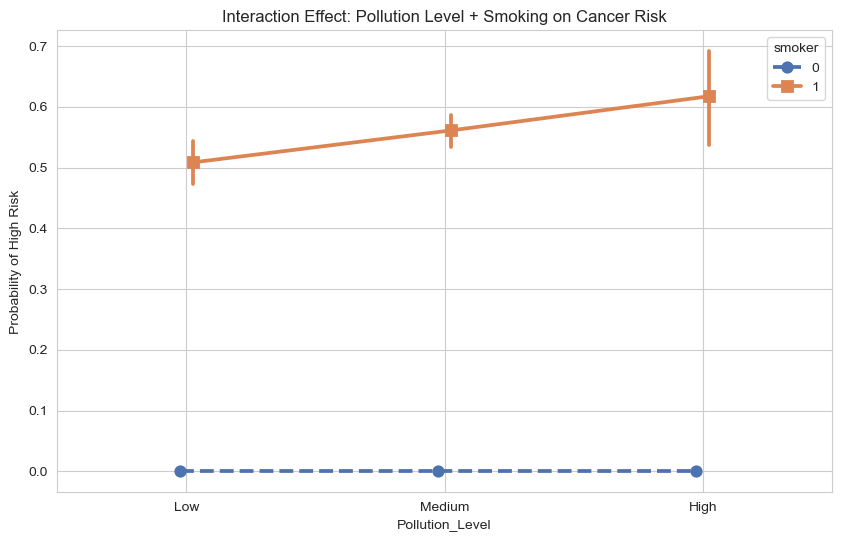

In [17]:
# Create a pivot table for visualization
# We bin pollution levels for easier plotting
df['Pollution_Level'] = pd.cut(df['air_pollution_index'], bins=3, labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(10, 6))
sns.pointplot(data=df, x='Pollution_Level', y='lung_cancer_risk', hue='smoker', 
              dodge=True, markers=['o', 's'], linestyles=['--', '-'], palette='deep')

plt.title('Interaction Effect: Pollution Level + Smoking on Cancer Risk')
plt.ylabel('Probability of High Risk')
plt.grid(True)
plt.show()

- The "Multiplier" Effect: This is a crucial finding. For non-smokers (Blue line), increasing pollution levels has almost no effect on cancer risk (the line is flat at 0).

- Vulnerability: For smokers (Orange line), the risk starts high (~0.5) and increases as pollution levels rise. This suggests that pollution primarily exacerbates the risk for individuals whose lungs are already compromised by smoking.

---

### 13. Summery Statisctics for Reporting


In [18]:
# Group by risk and check the mean of key numeric features
summary_stats = df.groupby('lung_cancer_risk')[['age', 'pack_years', 'air_pollution_index', 'oxygen_saturation']].mean()
print("Average Values by Risk Category:")
print(summary_stats)

print("\n---------------------------------")

# Check categorical prevalence
high_risk_smokers = df[df['lung_cancer_risk']==1]['smoker'].mean()
low_risk_smokers = df[df['lung_cancer_risk']==0]['smoker'].mean()

print(f"Percentage of Smokers in High Risk Group: {high_risk_smokers*100:.2f}%")
print(f"Percentage of Smokers in Low Risk Group:  {low_risk_smokers*100:.2f}%")

Average Values by Risk Category:
                        age  pack_years  air_pollution_index  \
lung_cancer_risk                                               
0                 53.992812    1.485623            63.717519   
1                 56.298232   20.631029            65.973473   

                  oxygen_saturation  
lung_cancer_risk                     
0                         97.593983  
1                         91.545820  

---------------------------------
Percentage of Smokers in High Risk Group: 100.00%
Percentage of Smokers in Low Risk Group:  27.42%


**Statistical Summary Findings**

- Dominance of Smoking: The most defining characteristic of the high-risk group is smoking behavior. 100% of individuals in the high-risk group are smokers, compared to only 27.42% in the low-risk group.

- Cumulative Exposure (Pack Years): This is further confirmed by the pack_years metric. High-risk patients have an average of 20.6 pack years, whereas low-risk patients average only 1.5 pack years. This massive gap indicates that long-term, intense exposure is a primary driver of risk.

- Respiratory Impact: There is a clear physiological decline in the high-risk group. Their average oxygen saturation drops to 91.5%, which is significantly lower than the healthy average of 97.6% seen in the low-risk group.

- Secondary Factors: interesting, age and air_pollution_index show only slight increases in the high-risk group (Age: 56 vs 54; Pollution: 66 vs 64). This suggests that while these factors contribute, they are likely less decisive than smoking habits and respiratory health markers in this specific dataset.

---

**Thank You!!!**